About the project
This study area includes 4 Wilderness Areas located in the Roosevelt National Forest of Northern Colorado. These area represent forests with minimal human-caused disturbances, so that existing forest cover types are more a result of ecological process rather than forest management practices.

Each observation is 30m x 30m forest cover type determined from US Forest Service (USFS) Region 2 Resource Information System (RIS) data. Independent variables were derived from the data originally obtained from US Geological Survey (USGS) and USFS data.

What needs to be done
We have been given a total of 54 attributes/features, these attributes contain Binary and Quantative attributes, and we need to predict which Forest Cover-Type is it from the given features.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import InputLayer # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
from sklearn.preprocessing import Normalizer
from tensorflow.keras.layers import Dense, Dropout, InputLayer # type: ignore
from tensorflow.keras.utils import to_categorical # type: ignore
from tensorflow.keras import layers # type: ignore
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

loading the data: Our data is in the .csv format and we load it with pandas: I use dataset as the variable.

In [489]:
dataset = pd.read_csv('cover_data.csv') 

In [ ]:
#To view the ten first rows of our data
dataset.head(10)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,class
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
5,2579,132,6,300,-15,67,230,237,140,6031,...,0,0,0,0,0,0,0,0,0,2
6,2606,45,7,270,5,633,222,225,138,6256,...,0,0,0,0,0,0,0,0,0,5
7,2605,49,4,234,7,573,222,230,144,6228,...,0,0,0,0,0,0,0,0,0,5
8,2617,45,9,240,56,666,223,221,133,6244,...,0,0,0,0,0,0,0,0,0,5
9,2612,59,10,247,11,636,228,219,124,6230,...,0,0,0,0,0,0,0,0,0,5


In [491]:
dataset.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40

In [ ]:
#view data columns and types
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [493]:
# Define feature columns and target variable
features = dataset.iloc[:, :-1]
labels = dataset.iloc[:, -1] - 1 

In [ ]:
print(features.describe())

           Elevation         Aspect          Slope  \
count  581012.000000  581012.000000  581012.000000   
mean     2959.365301     155.656807      14.103704   
std       279.984734     111.913721       7.488242   
min      1859.000000       0.000000       0.000000   
25%      2809.000000      58.000000       9.000000   
50%      2996.000000     127.000000      13.000000   
75%      3163.000000     260.000000      18.000000   
max      3858.000000     360.000000      66.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                     581012.000000                   581012.000000   
mean                         269.428217                       46.418855   
std                          212.549356                       58.295232   
min                            0.000000                     -173.000000   
25%                          108.000000                        7.000000   
50%                          218.000000                       3

In [495]:
training_features=features.columns

Split data into train and test sets:

In [ ]:
#Split data into train and test sets:
features_train, features_test, labels_train, labels_test = train_test_split(features, labels, test_size=0.4, random_state=42)
features_val, features_test, labels_val, labels_test = train_test_split(features_test, labels_test, test_size=0.5, random_state=42)

In [ ]:
 #check the shape of features_train and features_test
features_train.shape, features_test.shape

((348607, 54), (116203, 54))

In [ ]:
 #check data types in features_train
features_train.dtypes

Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64
Soil_Type9                      

To standardize the numerical features we use ColumnTransformer

In [ ]:
#scale the numeric training and test feature values
scaler = StandardScaler()
features_train = scaler.fit_transform(features_train)
features_val = scaler.transform(features_val)
features_test = scaler.transform(features_test)

In [ ]:
# Build the model
#create model instance with input, hidden and output lay
model = Sequential()
#The following code initializes an input layer for a DataFrame my_data that has 54 columns:
input = layers.InputLayer(input_shape=(features_train.shape[1],)) 
model.add(input)
model.add(Dense(128, input_dim=features_train.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Dropout regularization
model.add(Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(100, activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(7, activation='softmax'))

c:\Users\Ehich\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
c:\Users\Ehich\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#We’ll start by introducing the Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Define the early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [584]:
history = model.fit(features_train, labels_train, epochs=50, batch_size=500, validation_data=(features_val, labels_val), 
                    callbacks=[early_stopping])

Epoch 1/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8566 - loss: 0.3633 - val_accuracy: 0.8731 - val_loss: 0.3315
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8574 - loss: 0.3621 - val_accuracy: 0.8754 - val_loss: 0.3291
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8574 - loss: 0.3626 - val_accuracy: 0.8755 - val_loss: 0.3280
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8575 - loss: 0.3614 - val_accuracy: 0.8758 - val_loss: 0.3271
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8580 - loss: 0.3605 - val_accuracy: 0.8755 - val_loss: 0.3263
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8580 - loss: 0.3613 - val_accuracy: 0.8754 - val_loss: 0.3273
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8581 - loss: 0.3604 - val_accuracy: 0.8766 - val_loss: 0.3249
Epoch 8/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8582 - loss: 0.3592 - val_accuracy: 0.

Training and evaluating the model

In [585]:
model.save('covtype_classification_model.h5')

In [594]:
# Load the model (just to demonstrate loading)
loaded_model = tf.keras.models.load_model('covtype_classification_model.h5')

In [ ]:
# Evaluate the model on the test set and Generate a classification report ###
labels_pred = np.argmax(loaded_model.predict(features_test), axis=1)
print("Classification Report:\n", classification_report(labels_test, labels_pred))
print("Confusion Matrix:\n", confusion_matrix(labels_test, labels_pred))

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 3s 824us/step
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89     42218
           1       0.88      0.94      0.91     56895
           2       0.81      0.88      0.84      7075
           3       0.99      0.37      0.54       536
           4       0.80      0.52      0.63      1933
           5       0.74      0.62      0.68      3449
           6       0.94      0.84      0.88      4097

    accuracy                           0.89    116203
   macro avg       0.87      0.72      0.77    116203
weighted avg       0.89      0.89      0.88    116203

Confusion Matrix:
 [[36185  5779     2     0    38     2   212]
 [ 2529 53690   214     0   209   228    25]
 [    0   416  6213     1     0   445     0]
 [    0     0   279   198     0    59     0]
 [   30   848    42     0  1003    10     0]
 [    4   368   929     0     0  2148     0]
 [  584    78     0     0     5     0  3430]]

In [581]:
learning_rate=0.001

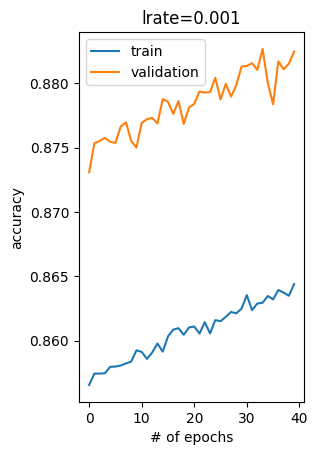

In [588]:

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('lrate=' + str(learning_rate))
plt.legend(loc="upper right")
plt.xlabel("# of epochs")
plt.ylabel("accuracy")
plt.legend()

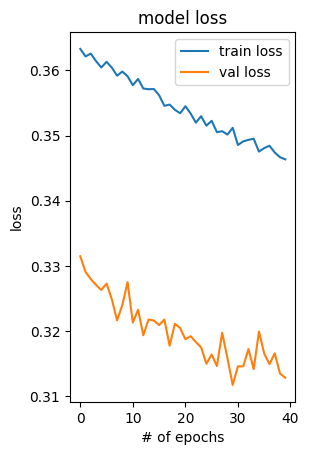

In [591]:
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('model loss')
plt.xlabel("# of epochs")
plt.ylabel("loss")
plt.legend()